In [1]:
%load_ext autoreload
%autoreload 2

# Set plotting parameters for figures
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

# Import catrace functions and load dataset configuration
from catrace.exp_collection import read_df
from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config('../dataset_configs/juvenile_dataset_t7.json')

In [2]:
import os
import pandas as pd
file_path = os.path.join(dsconfig.results_dir, 'offset_responsive_cluster')
os.makedirs(file_path, exist_ok=True)
# Read the matched labels
matched_label_df = pd.read_pickle(os.path.join(file_path, 'matched_cluster_labels.pkl'))

In [3]:
matched_label_df

Phe  Arg  Trp  \
fish_id                   condition plane neuron neuron_id                  
2021-07-15-DpOBEM-N2_Dp   naive     0     1      0            1    3    2   
                                          2      1            1    2    0   
                                          3      2            1    2    2   
                                          4      3            0    3    3   
                                          6      4            0    1    0   
...                                                         ...  ...  ...   
2021-11-26-DpOBEM-JH24_Dp phe-trp   3     209    1536         2    0    1   
                                          210    1537         1    3    0   
                                          211    1538         1    3    3   
                                          212    1539         2    1    1   
                                          213    1540         1    3    3   

                                                            TDCA  TCA  GCA  
fish_id                   condition plane neuron neuron_id                  
2021-07-15-DpOBEM-N2_Dp   naive     0     1      0             3    2    2  
                                          2      1             2    2    2  
                                          3      2             1    2    2  
                                          4      3             3    0    2  
                                          6      4             2    1    0  
...                                                          ...  ...  ...  
2021-11-26-DpOBEM-JH24_Dp phe-trp   3     209    1536          0    3    0  
                                          210    1537          3    2    2  
                                          211    1538          1    1    3  
                                          212    1539          0    3    1  
                                          213    1540          0    3    1  

[43211 rows x 6 columns]

In [4]:
# Do kmeans clustering of matched_label_df
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Function for clustering neurons based on timecourses
def cluster_neurons(dff, num_clusters, random_state=42, scale=True):
    X = dff.values.T  # shape (n_neurons, n_frames)

    if scale:
        # 2) Z-score each neuron across frames
        # StandardScaler works column-wise, so do it manually row-wise
        scaler = StandardScaler()
        Xz = scaler.fit_transform(X.T).T
    else:
        Xz = X

    # 3) Run k-means
    kmeans = KMeans(n_clusters=num_clusters, random_state=random_state)
    labels = kmeans.fit_predict(Xz)
    return labels

labels = cluster_neurons(matched_label_df.T, num_clusters=6)
labels.shape

(43211,)

In [5]:
def sort_dff_by_cluster(dff, labels):
    sorted_indices = np.argsort(labels)
    dff_sorted = dff.iloc[:, sorted_indices]
    labels_sorted = labels[sorted_indices]
    return dff_sorted, labels_sorted

dff_sorted, labels_sorted = sort_dff_by_cluster(matched_label_df.T, labels)

In [6]:
dff_sorted

fish_id   2021-03-19-DpOBEM-JH10_Dp 2022-02-13-DpOBEM-N10_Dp  \
condition                   phe-arg                    naive   
plane                             1                        0   
neuron                          129                       91   
neuron_id                       462                       88   
Phe                               3                        2   
Arg                               0                        0   
Trp                               2                        0   
TDCA                              3                        1   
TCA                               0                        0   
GCA                               2                        1   

fish_id   2021-04-02-DpOBEM-JH11_Dp 2021-10-02-DpOBEM-JH21_Dp  \
condition                   phe-arg                   arg-phe   
plane                             2                         2   
neuron                          169                        94   
neuron_id                       946                       943   
Phe                               3                         3   
Arg                               0                         3   
Trp                               3                         3   
TDCA                              2                         2   
TCA                               0                         2   
GCA                               3                         2   

fish_id   2021-09-17-DpOBEM-JH20_Dp 2021-11-10-DpOBEM-JH23_Dp  \
condition                   phe-arg                   phe-trp   
plane                             1                         2   
neuron                          462                       313   
neuron_id                       739                       901   
Phe                               2                         3   
Arg                               1                         1   
Trp                               1                         3   
TDCA                              1                         2   
TCA                               1                         2   
GCA                               0                         2   

fish_id   2021-11-24-DpOBEM-JH24_Dp 2021-04-02-DpOBEM-JH11_Dp      \
condition                   phe-trp                   phe-arg       
plane                             1                         2       
neuron                          258                       164 160   
neuron_id                       619                       941 937   
Phe                               3                         2   3   
Arg                               1                         2   3   
Trp                               3                         2   2   
TDCA                              2                         2   2   
TCA                               1                         1   2   
GCA                               1                         0   1   

fish_id   2021-09-17-DpOBEM-JH20_Dp  ... 2021-07-31-DpOBEM-JH17_Dp  \
condition                   phe-arg  ...                   arg-phe   
plane                             1  ...                         2   
neuron                          471  ...                       238   
neuron_id                       748  ...                       945   
Phe                               3  ...                         3   
Arg                               0  ...                         2   
Trp                               2  ...                         3   
TDCA                              2  ...                         0   
TCA                               1  ...                         1   
GCA                               0  ...                         3   

fish_id   2021-04-03-DpOBEM-JH11_Dp             2021-11-14-DpOBEM-JH23_Dp  \
condition                   phe-arg                               phe-trp   
plane                             2                                     0   
neuron                          147 144 141 137                        65   
neuron_id               

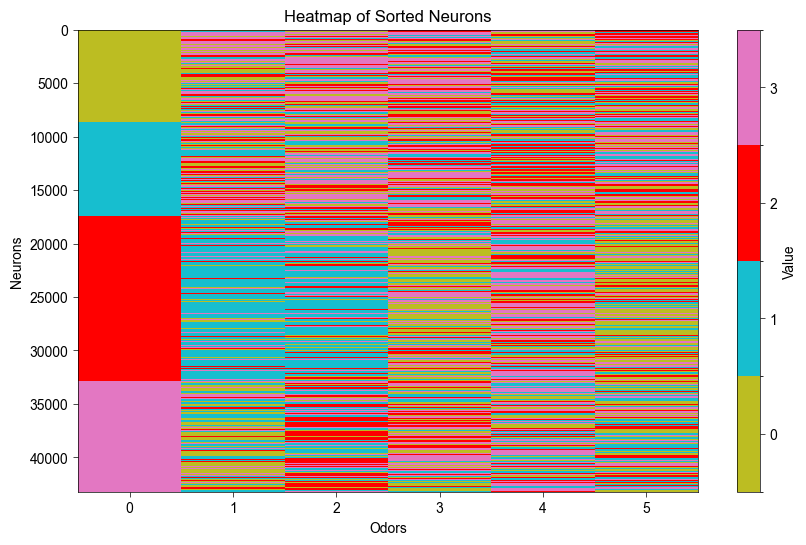

In [7]:
# Sort matched_label_df by Phe column
matched_label_df_sorted = matched_label_df.sort_values(by='Phe')


colors = ["tab:olive", "tab:cyan", "red", "tab:pink"]
def plot_heatmap_by_four_colors(dff_sorted, colors):
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=4)

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(
        dff_sorted.T.values,
        aspect='auto',
        cmap=cmap,
        norm=norm,
        interpolation='none'
    )

    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
    cbar.set_label('Value')

    ax.set_xlabel('Odors')
    ax.set_ylabel('Neurons')
    ax.set_title('Heatmap of Sorted Neurons')
    return fig, ax

fig, ax = plot_heatmap_by_four_colors(matched_label_df_sorted.T, colors)

In [8]:
# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure04')
os.makedirs(save_dir, exist_ok=True)
matched_label_df_sorted.to_csv(os.path.join(save_dir, f'extended_figure04b_offset_responsive_cluster_odor_specificity.csv'))